In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy, csv
import os, sys
import neurokit2 as nk
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))  # Add parent directory to sys.path
from datetime import datetime, timezone
from scipy.signal import resample, butter, filtfilt, find_peaks, hilbert, savgol_filter
from export_AF_Bed import *
from bed_info import *
plt.style.use('default')  # Use default style for better visibility of gridlines

In [62]:
def convert_mindray_n15_csv_to_resampled_npy(
    csv_path: str,
    fs_in: int = 500,
    fs_out: int = 100
):

    ecg_all = []
    ts_all = []

    dt_per_sample_ns = int(1e9 / fs_in)  # 原始采样点间隔

    # -------------------------
    # Step 1: 读原始 CSV
    # -------------------------
    with open(csv_path, "r", encoding="utf-8-sig") as f:
        reader = csv.reader(f)

        for row_idx, row in enumerate(reader):
            if not row:
                continue

            base_time_str = row[0].strip()

            try:
                base_time = pd.to_datetime(base_time_str)
            except Exception as e:
                raise ValueError(
                    f"第 {row_idx + 1} 行时间解析失败: {base_time_str}"
                ) from e

            sample_strs = row[1:]

            if len(sample_strs) != fs_in:
                raise ValueError(
                    f"第 {row_idx + 1} 行样本数不是 {fs_in}，而是 {len(sample_strs)}"
                )

            try:
                samples = np.array(sample_strs, dtype=np.float32)
            except Exception as e:
                raise ValueError(
                    f"第 {row_idx + 1} 行 ECG 数据转换失败"
                ) from e

            base_ns = np.datetime64(base_time.to_datetime64(), "ns")
            offsets = np.arange(fs_in, dtype=np.int64) * dt_per_sample_ns
            timestamps = base_ns + offsets.astype("timedelta64[ns]")

            ecg_all.append(samples)
            ts_all.append(timestamps)

    ecg = np.concatenate(ecg_all, axis=0)  # (N,)
    timestamps = np.concatenate(ts_all, axis=0)  # datetime64[ns], (N,)

    timestamps_resampled_ns, ecg_resampled = resample_with_timestamps(timestamps, ecg, target_fs=100)  # 测试函数是否正常运行
    return ecg_resampled, timestamps_resampled_ns
    # return ecg, timestamps


def clean_resampled_ecg_npy(
    data: np.ndarray,
    fs: int = 100,
    method: str = "neurokit"
):
    """
    读取 [timestamp_ns, ecg] 的 stacked npy，
    用 neurokit2 对 ECG 做去噪/清洗，并进一步去趋势，
    最后保存成新的 stacked npy。

    Parameters
    ----------
    input_path : str
        输入的 stacked npy 文件路径
    output_path : str
        输出的 cleaned stacked npy 文件路径
    fs : int
        采样率，默认 100 Hz
    method : str
        nk.ecg_clean 的方法，默认 "neurokit"
        可选如: "neurokit", "biosppy", "pantompkins1985", "hamilton2002", ...

    Returns
    -------
    cleaned_stacked : np.ndarray
        shape = (N, 2)
        [:, 0] = timestamp_ns
        [:, 1] = cleaned_ecg
    """

    # -------------------------
    # Step 1: 读取数据
    # -------------------------

    if data.ndim != 2 or data.shape[1] != 2:
        raise ValueError(f"输入数据 shape 应为 (N, 2)，当前为 {data.shape}")

    timestamp_ns = data[:, 0].astype(np.int64)
    ecg = data[:, 1].astype(np.float64)

    # -------------------------
    # Step 2: ECG 清洗（滤波 / 去噪）
    # -------------------------
    ecg_cleaned = nk.ecg_clean(ecg, sampling_rate=fs, method=method)

    # -------------------------
    # Step 3: 去趋势
    # order=1 常用于移除缓慢漂移
    # regularization 更平滑一些，也可换成 "polynomial"
    # -------------------------
    ecg_detrended = nk.signal_detrend(
        ecg_cleaned,
        method="polynomial",
        order=1
    )

    # -------------------------
    # Step 4: stack 保存
    # -------------------------
    cleaned_stacked = np.column_stack([
        timestamp_ns.astype(np.float64),
        ecg_detrended.astype(np.float64)
    ])

    return cleaned_stacked
def find_idx(target_time, timestamps, time_zone="Asia/Shanghai", exact=False):
    # Parse timestamps as timezone-aware UTC for reliable matching.
    ts = pd.to_datetime(timestamps, utc=True)
    
    # Interpret target_time in the provided timezone, then convert to UTC.
    target = pd.to_datetime(target_time)
    if target.tzinfo is None:
        target = target.tz_localize(time_zone)
    else:
        target = target.tz_convert(time_zone)
    target = target.tz_convert("UTC")
    
    if exact:
        matches = (ts == target)
        if matches.any():
            return matches.argmax()   # 第一个匹配位置
        else:
            raise ValueError(f"target_time {target} 不在 timestamps 中")
    else:
        # 找最近的时间点
        diff = abs(ts - target)
        return diff.argmin()
    

def norm_ecg(ECG):
    ECG = (ECG - np.min(ECG)) / (np.max(ECG) - np.min(ECG))
    return ECG
def timestamp_to_seconds(timestamps):
    # Convert ISO 8601 timestamps to seconds since the first timestamp
    base_time = pd.to_datetime(timestamps[0])
    seconds = [(pd.to_datetime(ts) - base_time).total_seconds()
               for ts in timestamps]
    return np.array(seconds)
def butter_bandpass(x, fs, lo=0.5, hi=30.0, order=3):
    b, a = butter(order, [lo, hi], btype='band', fs=fs)
    return filtfilt(b, a, x)

def lowpass(x, fs, fc=0.6, order=3):
    b, a = butter(order, fc, btype='low', fs=fs)
    return filtfilt(b, a, x)

def _butter_bandpass(low, high, fs, order=3):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return b, a
def extract_hilbert_envelope_and_remove(
    x: np.ndarray,
    smooth_win: int | None = None,
    smooth_poly: int = 3,
    remove_method: str = "divide",
    eps: float = 1e-8,
):
    """
    计算 Hilbert 包络，并从原始信号中去除包络。

    参数
    ----
    x : 1D numpy array，信号取值在 [0, 1] 或任意实数范围均可
    smooth_win : 可选，对包络做 Savitzky–Golay 平滑的窗口长度(奇数)。None 表示不平滑
    smooth_poly : Savitzky–Golay 的多项式阶数（通常 2 或 3 即可）
    remove_method : "divide" 或 "subtract"
        - "divide": 按包络幅度进行幅度解调 y = x / (env + eps)
        - "subtract": 直接相减 y = x - env
    eps : 防止除零的微小常数

    返回
    ----
    env : np.ndarray, Hilbert 包络（可选已平滑）
    y   : np.ndarray, 去除包络后的信号
    """
    x = butter_bandpass(x, 100)
    x= np.pad(x, (20,0), 'edge')
    x = np.asarray(x, dtype=float).ravel()

    # 1) Hilbert 分析信号与包络
    analytic = hilbert(x)
    env = np.abs(analytic)

    # 2) 可选：对包络做平滑（建议 smooth_win 为奇数且 >= 5）
    if smooth_win is not None and smooth_win >= 5 and smooth_win % 2 == 1:
        # 若窗口过小或长度超过信号，会自动调整到合适范围
        win = min(smooth_win, len(env) - (1 - len(env) % 2))
        win = max(win, 5 if (5 <= len(env)) else (len(env) | 1))  # 保证奇数
        if win >= 5 and win % 2 == 1 and win <= len(env):
            env = savgol_filter(env, window_length=win, polyorder=min(smooth_poly, win - 2))

    # 3) 去除包络
    remove_method = remove_method.lower()
    if remove_method == "divide":
        # 常用于幅度解调：保留载波/细节，移除慢变幅度
        y = x / (env + eps)
        # 可选：把结果移回零均值或原范围（按需再处理）
        y[20:] = (y[20:] - np.mean(y[20:]))+np.mean(x[20:])  # 如果你希望零均值，可取消注释
    elif remove_method == "subtract":
        # 直接减去包络，得到高频残差（更像去慢趋势）
        y = x - env
    else:
        raise ValueError("remove_method 只能是 'divide' 或 'subtract'。")
    temp = y[20:]
    # rescale to original amplitude
    y[20:] = (temp - np.min(temp)) / (np.max(temp) - np.min(temp)) * (np.max(x[20:]) - np.min(x[20:])) + np.min(x[20:])
    return env[20:], y[20:]
def resample_signal(x, original_fs, target_fs):
    num_samples = int(len(x) * target_fs / original_fs)
    return resample(x, num_samples)


def resample_with_timestamps(timestamps, x, target_fs):
    """
    根据原始时间戳和信号值，重采样到目标采样率

    Parameters
    ----------
    timestamps : array-like
        可被 pandas.to_datetime 解析的时间戳序列
    x : array-like
        对应信号值
    target_fs : float
        目标采样率，例如 100 Hz

    Returns
    -------
    new_timestamps : pd.DatetimeIndex
        重采样后的时间戳
    x_new : np.ndarray
        重采样后的信号
    """
    timestamps = pd.to_datetime(timestamps)
    x = np.asarray(x)

    if len(timestamps) != len(x):
        raise ValueError("timestamps 和 x 长度必须一致")
    sort_idx = np.argsort(timestamps)
    timestamps = timestamps[sort_idx]
    x = x[sort_idx]
    # 转成相对秒
    t0 = timestamps[0]
    t_sec = (timestamps - t0).total_seconds().to_numpy()

    # 生成新的等间隔时间轴
    dt = 1.0 / target_fs
    t_new_sec = np.arange(t_sec[0], t_sec[-1], dt)

    # 线性插值
    x_new = np.interp(t_new_sec, t_sec, x)
    # print(x_new)
    # 生成新的时间戳
    new_timestamps = t0 + pd.to_timedelta(t_new_sec, unit="s")

    return new_timestamps.astype("int64"), x_new


In [63]:
root_path = './data/'
target_path = './data_final/'
fs = 100

In [64]:
def new_struct():
    data_struct = {
        "Info" : {
            "Subject" : None, # -1 means chirp wave, 0-9 means real human subjects
            "Bed_angle" : None, # 0°, 10°,  20°, 30°
            "Posture" : None, # Back, Left side, Right side, Stomach
            "Test" : None, # Post exercise (PE), Cold pressor test (CP), Valsalva (VA)
            "Other_comment" : None,
        },
        # can add bed if needed
        "Bed_ID" : 'AF', # can be: AF, 5, 9, 3, 1, 7, 6, 10, 11, 12, 13, 15
        "BD_up" : None, # BedDot upper sensor, [BSG_x, BSG_y, BSG_z]
        "SCG_z" : None,
        "ECG" : None,
        "ABP" : None,
        "Timestamp" : None,

        # The following items are only used for AF Bed with 3 sets of BedDot
        "BD_compare" : None, # BedDot compare sensor, [BSG_x, BSG_y, BSG_z]
        "BD_mid" : None, # BedDot middle sensor, [BSG_x, BSG_y, BSG_z]
    }
    return data_struct


In [65]:
# selected_bed = bed_AF_ID_30_compare
# selected_bed['SID']
# f'./data/{selected_bed["SID"]}_{status}.npy'

### Info. of the current trial

In [66]:
status = 'chirp_womat_'
status = 'chirp_mat_2weights_'
cur_struct = new_struct()
cur_struct['Bed_ID'] = 'AF'
cur_struct['Info']['Subject'] = 0
cur_struct['Info']['Bed_angle'] = 0
cur_struct['Info']['Posture'] = 'Back'
cur_struct['Info']['Test'] = 'Normal'
cur_struct['Info']['Other_comment'] = None

### Read BedDot data

In [67]:
selected_bed = bed_AF_ID_30_up
bed_reading = np.load(f'../data/{selected_bed["SID"]}_{status}.npy', allow_pickle=True).item()
signal_30 = bed_reading['data']
BSG_timestamps = bed_reading['timestamps']

# selected_bed = bed_AF_ID_30_compare
# bed_reading_2 = np.load(f'../data/{selected_bed["SID"]}_{status}.npy', allow_pickle=True).item()
# signal_cp = bed_reading_2['data']
# selected_bed = bed_AF_ID_18_mid
# bed_reading_3 = np.load(f'../data/{selected_bed["SID"]}_{status}.npy', allow_pickle=True).item()
# signal_mid = bed_reading_3['data']
selected_bed = bed_AF_ID_on
bed_reading_4 = np.load(f'../data/{selected_bed["SID"]}_{status}.npy', allow_pickle=True).item()
signal_on = bed_reading_4['data']

Selected time window: 2026-3-16 15:55:50 to 2026-3-16 16:05:25 
Corresponding to indices 97000 to 98200 in BSG timestamps.


Text(0.5, 1.0, 'BSG vs. SCG')

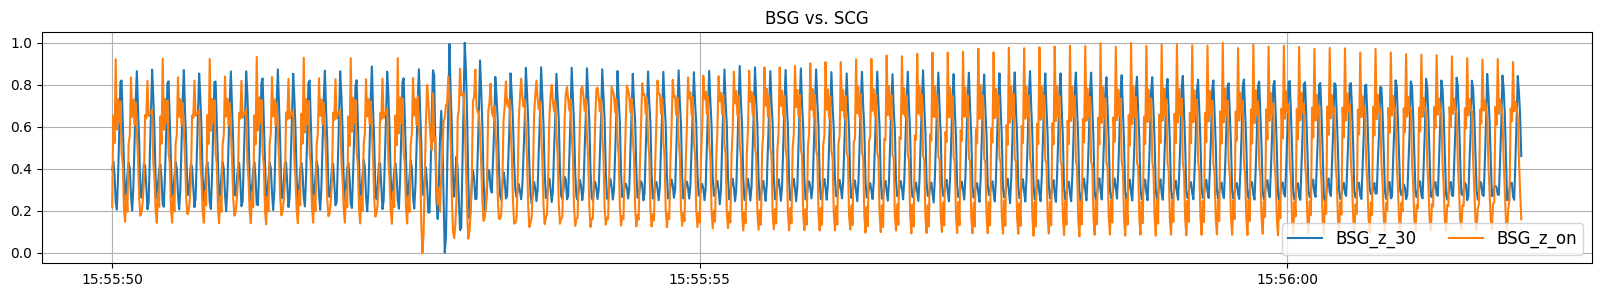

In [76]:
start_time = "2026-3-16 15:55:50"
end_time = "2026-3-16 16:05:25"
start_bsg = find_idx(start_time, BSG_timestamps, "Asia/Shanghai")
# end = find_idx(end_time, BSG_timestamps, "Asia/Shanghai")
end_bsg = start_bsg + 1200
print(f"Selected time window: {start_time} to {end_time} \nCorresponding to indices {start_bsg} to {end_bsg} in BSG timestamps.")
# start = 0
t = pd.to_datetime(BSG_timestamps) + pd.to_timedelta(8, unit='h')  # 转换为上海时间
plt.figure(figsize=(20, 3))
plt.plot(t[start_bsg:end_bsg], norm_ecg(signal_30[2, start_bsg:end_bsg])+0, label='BSG_z_30')
# plt.plot(t[start_bsg:end_bsg], norm_ecg(signal_cp[2, start_bsg:end_bsg])+1, label='BSG_z_cp')
# plt.plot(t[start_bsg:end_bsg], norm_ecg(signal_mid[2, start_bsg:end_bsg])+2, label='BSG_z_18')
plt.plot(t[start_bsg:end_bsg], norm_ecg(signal_on[2, start_bsg:end_bsg])+0, label='BSG_z_on')
plt.legend(loc='lower right', fontsize=12, ncol=3)
plt.grid()
plt.title(f'BSG vs. SCG')

In [69]:
len(signal_30), len(y)

(3, 100)

step 00, f =    0.800 Hz, usable idx = [500, 2499]
step 01, f =    1.004 Hz, usable idx = [3500, 5499]
step 02, f =    1.209 Hz, usable idx = [6500, 8499]
step 03, f =    1.413 Hz, usable idx = [9500, 11499]
step 04, f =    1.618 Hz, usable idx = [12500, 14499]
step 05, f =    1.822 Hz, usable idx = [15500, 17499]
step 06, f =    2.027 Hz, usable idx = [18500, 20499]
step 07, f =    2.231 Hz, usable idx = [21500, 23499]
step 08, f =    2.436 Hz, usable idx = [24500, 26499]
step 09, f =    2.640 Hz, usable idx = [27500, 29499]
step 10, f =    2.844 Hz, usable idx = [30500, 32499]
step 11, f =    3.049 Hz, usable idx = [33500, 35499]
step 12, f =    3.253 Hz, usable idx = [36500, 38499]
step 13, f =    3.458 Hz, usable idx = [39500, 41499]
step 14, f =    3.662 Hz, usable idx = [42500, 44499]
step 15, f =    3.867 Hz, usable idx = [45500, 47499]
step 16, f =    4.071 Hz, usable idx = [48500, 50499]
step 17, f =    4.276 Hz, usable idx = [51500, 53499]
step 18, f =    4.480 Hz, usable idx

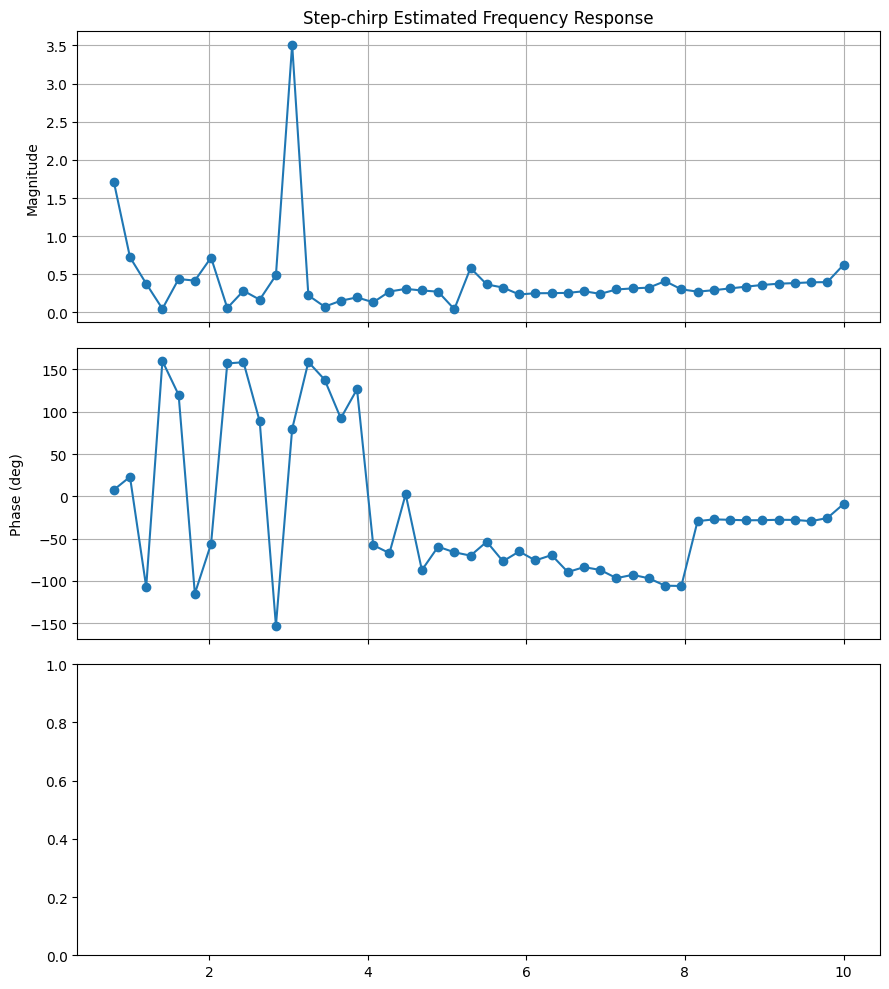

In [74]:
x = signal_on[2, start_bsg:start_bsg+1380*100]
y = signal_30[2, start_bsg:start_bsg+1380*100]
import numpy as np
import matplotlib.pyplot as plt


def fit_single_tone(sig, f0, fs):
    """
    在已知频率 f0 下，对信号做单频正弦拟合：
        sig(t) ≈ a*cos(wt) + b*sin(wt) + c

    返回
    ----
    phasor : complex
        复数相量，满足 sig(t) ≈ Re{phasor * exp(jwt)} + c
    amp : float
        该频率分量幅值
    phase_rad : float
        该频率分量相位（弧度）
    offset : float
        直流项
    r2 : float
        拟合优度
    sig_hat : ndarray
        拟合波形
    """
    sig = np.asarray(sig).astype(float).squeeze()
    n = len(sig)
    t = np.arange(n) / fs
    w = 2 * np.pi * f0

    A = np.column_stack([
        np.cos(w * t),
        np.sin(w * t),
        np.ones(n)
    ])

    coef, *_ = np.linalg.lstsq(A, sig, rcond=None)
    a, b, c = coef

    # sig(t) = a cos(wt) + b sin(wt) + c
    # 对应复相量 phasor = a - j b
    phasor = a - 1j * b
    amp = np.abs(phasor)
    phase_rad = np.angle(phasor)

    sig_hat = A @ coef

    ss_res = np.sum((sig - sig_hat) ** 2)
    ss_tot = np.sum((sig - np.mean(sig)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return phasor, amp, phase_rad, c, r2, sig_hat


def estimate_step_chirp_frf(
    x,
    y,
    freqs,
    fs=100,
    step_duration=30,
    discard_start=5,
    discard_end=5,
    min_input_amp=1e-12,
):
    """
    对 step-chirp 输入输出信号估计频率响应

    Parameters
    ----------
    x : 1D array
        输入信号
    y : 1D array
        输出信号
    freqs : 1D array
        每个 step 对应的频率（Hz），长度 = step 数
    fs : float
        采样率（Hz）
    step_duration : float
        每个频率持续时间（秒）
    discard_start : float
        每段前面丢弃的秒数
    discard_end : float
        每段后面丢弃的秒数
    min_input_amp : float
        若输入在该频点的拟合幅值太小，则该点记为 NaN

    Returns
    -------
    results : dict
        包含每个频点的 FRF、gain、phase、拟合质量等
    """
    x = np.asarray(x).astype(float).squeeze()
    y = np.asarray(y).astype(float).squeeze()
    freqs = np.asarray(freqs).astype(float).squeeze()

    if x.ndim != 1 or y.ndim != 1:
        raise ValueError("x 和 y 必须都是一维信号")
    if len(x) != len(y):
        raise ValueError("x 和 y 长度必须一致")

    n_step = int(round(fs * step_duration))
    n_discard_start = int(round(fs * discard_start))
    n_discard_end = int(round(fs * discard_end))

    if n_discard_start + n_discard_end >= n_step:
        raise ValueError("discard_start + discard_end 不能超过单段长度")

    required_len = len(freqs) * n_step
    if len(x) < required_len:
        raise ValueError(
            f"信号长度不够。需要至少 {required_len} 点，但当前只有 {len(x)} 点。"
        )

    # 如果信号更长，只取前面与 freqs 对应的部分
    x = x[:required_len]
    y = y[:required_len]

    H_list = []
    gain_list = []
    gain_db_list = []
    phase_deg_list = []
    x_amp_list = []
    y_amp_list = []
    x_r2_list = []
    y_r2_list = []
    idx_ranges = []

    for k, f0 in enumerate(freqs):
        full_start = k * n_step
        full_end = (k + 1) * n_step

        use_start = full_start + n_discard_start
        use_end = full_end - n_discard_end

        x_seg = x[use_start:use_end]
        y_seg = y[use_start:use_end]

        Xk, x_amp, x_phase, _, x_r2, _ = fit_single_tone(x_seg, f0, fs)
        Yk, y_amp, y_phase, _, y_r2, _ = fit_single_tone(y_seg, f0, fs)

        if x_amp < min_input_amp:
            Hk = np.nan + 1j * np.nan
            gain = np.nan
            gain_db = np.nan
            phase_deg = np.nan
        else:
            Hk = Yk / Xk
            gain = np.abs(Hk)
            gain_db = 20 * np.log10(gain) if gain > 0 else np.nan
            phase_deg = np.rad2deg(np.angle(Hk))

        H_list.append(Hk)
        gain_list.append(gain)
        gain_db_list.append(gain_db)
        phase_deg_list.append(phase_deg)
        x_amp_list.append(x_amp)
        y_amp_list.append(y_amp)
        x_r2_list.append(x_r2)
        y_r2_list.append(y_r2)
        idx_ranges.append((use_start, use_end - 1))

    results = {
        "freqs": freqs,
        "H": np.asarray(H_list),
        "gain": np.asarray(gain_list),
        "gain_db": np.asarray(gain_db_list),
        "phase_deg": np.asarray(phase_deg_list),
        "x_amp": np.asarray(x_amp_list),
        "y_amp": np.asarray(y_amp_list),
        "x_r2": np.asarray(x_r2_list),
        "y_r2": np.asarray(y_r2_list),
        "usable_idx_ranges": idx_ranges,
        "fs": fs,
        "step_duration": step_duration,
        "discard_start": discard_start,
        "discard_end": discard_end,
    }
    return results


def wrap_phase_deg(phase_deg):
    """
    把相位包裹到 [-180, 180)
    """
    phase_deg = np.asarray(phase_deg)
    return (phase_deg + 180) % 360 - 180


def plot_step_chirp_frf(results, sort_by_freq=True, unwrap_phase=False):
    """
    画 step-chirp 的频率响应
    """
    freqs = results["freqs"].copy()
    gain = results["gain"].copy()
    gain_db = results["gain_db"].copy()
    phase_deg = results["phase_deg"].copy()
    x_r2 = results["x_r2"].copy()
    y_r2 = results["y_r2"].copy()

    if sort_by_freq:
        idx = np.argsort(freqs)
        freqs = freqs[idx]
        gain = gain[idx]
        gain_db = gain_db[idx]
        phase_deg = phase_deg[idx]
        x_r2 = x_r2[idx]
        y_r2 = y_r2[idx]

    if unwrap_phase:
        phase_plot = np.rad2deg(np.unwrap(np.deg2rad(phase_deg)))
    else:
        phase_plot = wrap_phase_deg(phase_deg)

    fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

    axes[0].plot(freqs, gain, 'o-', linewidth=1.5)
    axes[0].set_ylabel('Magnitude')
    axes[0].set_title('Step-chirp Estimated Frequency Response')
    axes[0].grid(True)
    # axes[0].set_ylim(-0.1, 5)

    axes[1].plot(freqs, phase_plot, 'o-', linewidth=1.5)
    axes[1].set_ylabel('Phase (deg)')
    axes[1].grid(True)

    # axes[2].plot(freqs, x_r2, 'o-', label='Input fit $R^2$')
    # axes[2].plot(freqs, y_r2, 's-', label='Output fit $R^2$')
    # axes[2].set_ylabel('$R^2$')
    # axes[2].set_xlabel('Frequency (Hz)')
    # axes[2].set_ylim(0, 1.05)
    # axes[2].grid(True)
    # axes[2].legend()

    plt.tight_layout()
    plt.show()


def print_step_ranges(results):
    """
    打印每个频率段实际使用的 idx 范围
    """
    freqs = results["freqs"]
    idx_ranges = results["usable_idx_ranges"]

    for k, (f0, (s, e)) in enumerate(zip(freqs, idx_ranges)):
        print(f"step {k:02d}, f = {f0:8.3f} Hz, usable idx = [{s}, {e}]")

freqs = np.round(np.linspace(0.8, 10.0, 46), 10)

results = estimate_step_chirp_frf(
    x=x,
    y=y,
    freqs=freqs,
    fs=100,
    step_duration=30,
    discard_start=5,
    discard_end=5,
)

print_step_ranges(results)
plot_step_chirp_frf(results, sort_by_freq=True, unwrap_phase=False)


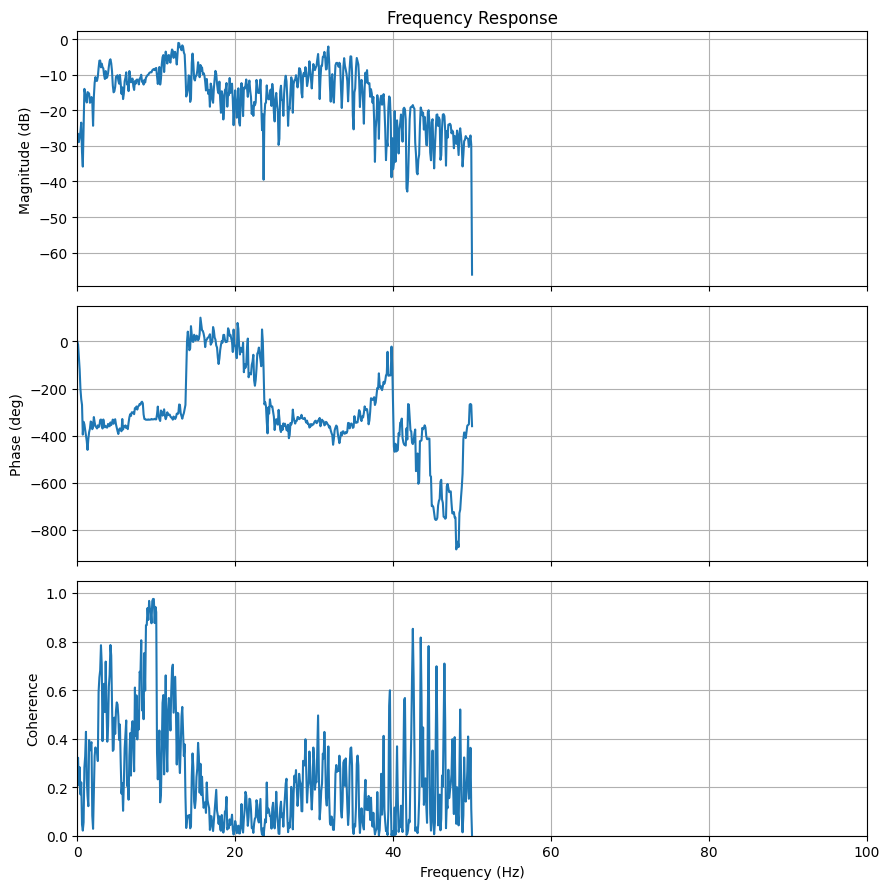

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


def estimate_frf(x, y, fs, nperseg=4096, noverlap=None, window='hann'):
    """
    估计系统频率响应 H(f) = S_yx / S_xx

    Parameters
    ----------
    x : array-like
        输入信号，一维
    y : array-like
        输出信号，一维
    fs : float
        采样率 (Hz)
    nperseg : int
        Welch/CSD 每段长度
    noverlap : int or None
        重叠长度，默认 nperseg // 2
    window : str
        窗函数

    Returns
    -------
    f : ndarray
        频率轴 (Hz)
    H : ndarray
        复数频率响应
    coh : ndarray
        相干函数 coherence，用于判断估计是否可靠
    """
    x = np.asarray(x).squeeze()
    y = np.asarray(y).squeeze()

    if x.ndim != 1 or y.ndim != 1:
        raise ValueError("x 和 y 必须都是一维信号")
    if len(x) != len(y):
        raise ValueError("x 和 y 长度必须相同")

    if noverlap is None:
        noverlap = nperseg // 2

    # 输入自功率谱 Sxx
    f, Sxx = signal.welch(
        x, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap,
        detrend='constant', return_onesided=True, scaling='density'
    )

    # 输出-输入互功率谱 Syx
    _, Syx = signal.csd(
        y, x, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap,
        detrend='constant', return_onesided=True, scaling='density'
    )

    # H1 estimator
    H = Syx / Sxx

    # coherence
    _, coh = signal.coherence(
        x, y, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap,
        detrend='constant'
    )

    return f, H, coh


def plot_frf(f, H, coh=None, fmin=None, fmax=None, unwrap_phase=True):
    """
    画频率响应：幅值(dB) + 相位(deg) + coherence(可选)
    """
    mag_db = 20 * np.log10(np.maximum(np.abs(H), 1e-15))
    phase = np.angle(H)
    if unwrap_phase:
        phase = np.unwrap(phase)
    phase_deg = np.rad2deg(phase)

    if coh is None:
        fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
        ax1, ax2 = axes
    else:
        fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
        ax1, ax2, ax3 = axes

    ax1.plot(f, mag_db)
    ax1.set_ylabel('Magnitude (dB)')
    ax1.set_title('Frequency Response')
    ax1.grid(True)

    ax2.plot(f, phase_deg)
    ax2.set_ylabel('Phase (deg)')
    ax2.grid(True)

    if coh is not None:
        ax3.plot(f, coh)
        ax3.set_ylabel('Coherence')
        ax3.set_xlabel('Frequency (Hz)')
        ax3.set_ylim(0, 1.05)
        ax3.grid(True)
    else:
        ax2.set_xlabel('Frequency (Hz)')

    if fmin is not None or fmax is not None:
        for ax in axes:
            ax.set_xlim(left=fmin, right=fmax)

    plt.tight_layout()
    plt.show()



fs = 100  # 采样率 Hz
# 估计频响
f, H, coh = estimate_frf(signal_on[2], signal_30[2], fs, nperseg=1000)

# 画图
plot_frf(f, H, coh=coh, fmin=0, fmax=100)

In [72]:

# Define sampling parameters
fs = 100.0  # Sampling frequency in Hz
t = np.arange(0, 1.0, 1.0/fs)  # Time vector for 1 second

# Generate an input signal x
# White noise is ideal for frequency response estimation as it contains all frequencies
x = np.random.randn(len(t))

# Define a simulated system (e.g., a 4th-order Butterworth lowpass filter)
# Cutoff frequency is set to 100 Hz
cutoff_freq = 10.0
b, a = signal.butter(4, cutoff_freq / (fs / 2.0), 'low')

# Generate the output signal y by passing input x through the system
y = signal.lfilter(b, a, x)
y = signal_cp[2]
x = signal_on[2]
# ==========================================
# Frequency Response Estimation using Welch's Method
# ==========================================

# Estimate the cross power spectral density (Pxy) of input and output
f, Pxy = signal.csd(x, y, fs=fs, nperseg=8)

# Estimate the power spectral density (Pxx) of the input
f, Pxx = signal.welch(x, fs=fs, nperseg=8)

# Calculate the frequency response H(f) = Pxy(f) / Pxx(f)
H = Pxy / Pxx

# Calculate magnitude in Decibels (dB) and phase in Degrees
magnitude_dB = 20 * np.log10(np.abs(H))
magnitude_dB =np.abs(H)
phase_deg = np.angle(H, deg=True)

# ==========================================
# Plotting the Results
# ==========================================

plt.figure(figsize=(10, 8))

# Magnitude plot
plt.subplot(2, 1, 1)
plt.plot(f, magnitude_dB, color='b')  # Logarithmic scale for frequency is common
plt.title('System Frequency Response / Bode Plot')
plt.ylabel('Magnitude (dB)')
plt.grid(True, which="both", ls="-")


NameError: name 'signal_cp' is not defined

In [ ]:
dfd

NameError: name 'dfd' is not defined

### Read SCG data (need manually time sync)

In [ ]:
scg_file = f'../data/device_device1_{status}.npy'
SCG_org_fs = 62
scg_reading = np.load(scg_file, allow_pickle=True)
scg_reading.shape
ts_scg = scg_reading[:, 0]
scg_z = (scg_reading[:, 3])
true_len_scg = (BSG_timestamps[-1]-BSG_timestamps[0])/1e9 * SCG_org_fs
print(len(scg_reading[:, 3]), true_len_scg) if np.abs(len(scg_reading[:, 3]) - true_len_scg) > 1 else print("SCG length matches expected length based on timestamps.")

ts_scg, scg_z = resample_with_timestamps(ts_scg, scg_z, target_fs = 100)
# env, scg_z = extract_hilbert_envelope_and_remove(scg_z, smooth_win=101, remove_method="divide")
print(len(signal[0]), len(scg_reading[:, 3]),  len(scg_z))

# shanghai timezone is UTC+8, so we need to add 8 hours to the timestamps
dt_scg = pd.to_datetime(ts_scg[0], unit='ns')
dt_bsg = pd.to_datetime(BSG_timestamps[-1], unit='ns') 
print(f"Last timestamp of SCG: {dt_scg}, Last timestamp of BSG: {dt_bsg}")


FileNotFoundError: [Errno 2] No such file or directory: '../data/device_device1_chirp_womat_.npy'

Selected time window: 2026-3-16 16:05:10 to 2026-3-16 16:09:04 
Corresponding to indices 6900 to 7900 in BSG timestamps.


Text(0.5, 1.0, 'BSG vs. SCG')

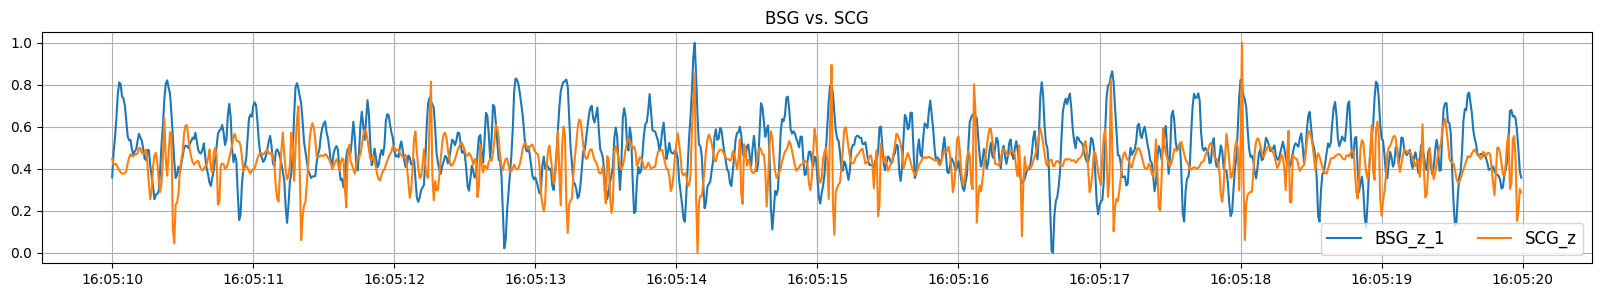

In [ ]:
# check the time synchronization between SCG and BSG
start_time = "2026-3-16 16:05:10"
end_time = "2026-3-16 16:09:04"
start_bsg = find_idx(start_time, BSG_timestamps, "Asia/Shanghai")
# end = find_idx(end_time, BSG_timestamps, "Asia/Shanghai")
end_bsg = start_bsg + 1000
print(f"Selected time window: {start_time} to {end_time} \nCorresponding to indices {start_bsg} to {end_bsg} in BSG timestamps.")

# start = 0
# end = start +1000
t = pd.to_datetime(BSG_timestamps) + pd.to_timedelta(8, unit='h')  # 转换为上海时间
t_scg = pd.to_datetime(ts_scg) + pd.to_timedelta(8, unit='h')  # 转换为上海时间
plt.figure(figsize=(20, 3))
plt.plot(t[start_bsg:end_bsg], norm_ecg(signal[2, start_bsg:end_bsg])+0, label='BSG_z_1')
# plt.plot(t[:], norm_ecg(signal[2, :])+0, label='BSG_z_1')
shift_scg = int(fs*2.23)
# shift = int(fs*0.2)
plt.plot(t[start_bsg:end_bsg], norm_ecg(scg_z[start_bsg+shift_scg:end_bsg+shift_scg]), label='SCG_z', alpha=1)
plt.legend(loc='lower right', fontsize=12, ncol=3)
plt.grid()
plt.title(f'BSG vs. SCG')

### Read ECG

In [ ]:


ecg_path = '../data/ECG_data/ECG_II-20260316105822~20260316112601.csv'

ecg_resampled, date_time = convert_mindray_n15_csv_to_resampled_npy(
    csv_path=ecg_path,
    fs_in=500,
    fs_out=100
)
# cleaned_data = clean_resampled_ecg_npy(
#     data=np.column_stack([date_time.astype(np.float64), ecg_resampled.astype(np.float64)]),
#     fs=100,
#     method="neurokit"
# )


In [ ]:
(pd.to_datetime(date_time[-1]) - pd.to_datetime(date_time[0])).total_seconds(), len(ecg_resampled)
# (date_time[-1]-date_time[0]).total_seconds()

(1659.99, 166000)

Selected time window: 2026-3-16 11:02:40 to 2026-3-16 11:01:30 
Corresponding to indices 25800 to 26800 in ECG timestamps.


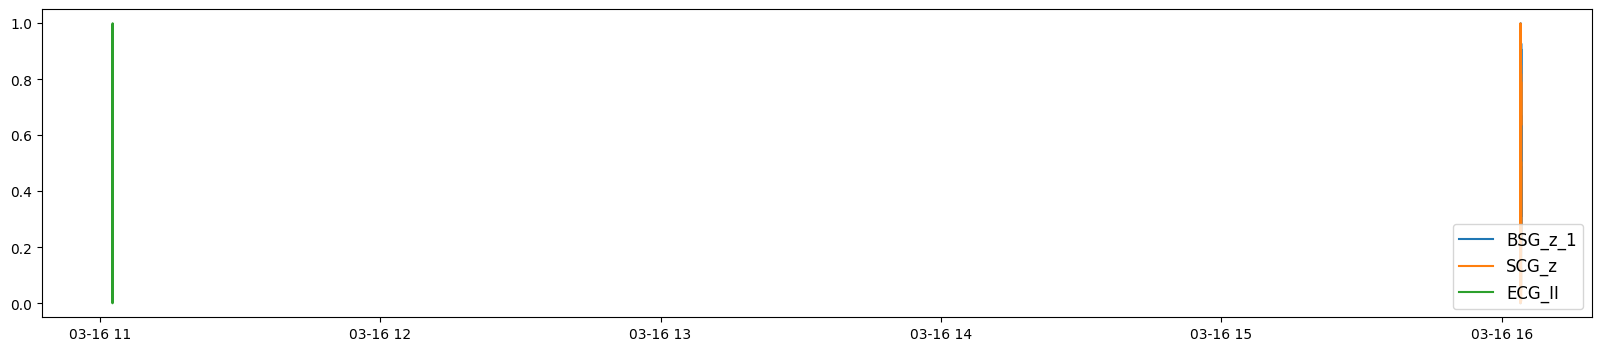

In [ ]:
# plot the signal
ecg = ecg_resampled
ecg_ts = pd.to_datetime(date_time.astype(np.int64), unit='ns') - pd.to_timedelta(8, unit='h') 
ecg_t = pd.to_datetime(ecg_ts) + pd.to_timedelta(8, unit='h')    # 转换为上海时间
# ecg_ts = BSG_timestamps
length = 1000
start_time = "2026-3-16 11:02:40"
end_time = "2026-3-16 11:01:30"
start_ecg = find_idx(start_time, ecg_ts, "Asia/Shanghai")
end_ecg = find_idx(end_time, ecg_ts, "Asia/Shanghai")
start_bsg = find_idx(start_time, BSG_timestamps, "Asia/Shanghai")
end_bsg = start_bsg + length
# start = start - 500
end_ecg = start_ecg + length
print(f"Selected time window: {start_time} to {end_time} \nCorresponding to indices {start_ecg} to {end_ecg} in ECG timestamps.")
shift_time = -2.16
shift_ecg = int(100*shift_time)
shift_scg = int(100*2.15)
plt.figure(figsize=(20, 4))
plt.plot(t[start_bsg:end_bsg], norm_ecg(signal[2, start_bsg:end_bsg])+0, label='BSG_z_1')
plt.plot(t_scg[start_bsg:end_bsg], norm_ecg(scg_z[start_bsg+shift_scg:end_bsg+shift_scg]), label='SCG_z', alpha=1)
plt.plot(ecg_t[start_ecg:end_ecg], norm_ecg(ecg[start_ecg+shift_ecg:end_ecg+shift_ecg]), label='ECG_II')
# plt.plot(ecg_t, ecg, label='ECG_II')
plt.legend(loc='lower right', fontsize=12)

### Save struct

In [ ]:
cur_struct['Timestamp'] = BSG_timestamps
cur_struct['BD_up'] = signal[2, start_bsg:end_bsg]
cur_struct['SCG_z'] = scg_z[start_bsg+shift_scg:end_bsg+shift_scg]
cur_struct['ECG'] = ecg[start_ecg+shift_ecg:end_ecg+shift_ecg]
if cur_struct['Bed_ID'] == 'AF':
    selected_bed = bed_AF_ID_30_compare
    bed_reading_2 = np.load(f'../data/{selected_bed["SID"]}_{status}.npy', allow_pickle=True).item()
    selected_bed = bed_AF_ID_18_mid
    bed_reading_3 = np.load(f'../data/{selected_bed["SID"]}_{status}.npy', allow_pickle=True).item()
    cur_struct['BD_compare'] = bed_reading_2['data'][2, start_bsg:end_bsg]
    cur_struct['BD_mid'] = bed_reading_3['data'][2, start_bsg:end_bsg]
cur_struct

{'Info': {'Subject': 0,
  'Bed_angle': 0,
  'Posture': 'Back',
  'Test': 'Normal',
  'Other_comment': None},
 'Bed_ID': 'AF',
 'BD_up': array([-1.71110e+04, -5.05190e+04, -6.51790e+04, -2.90200e+04,
         4.13000e+04,  1.00508e+05,  7.25900e+04,  2.28850e+04,
         4.27600e+03,  6.21200e+03,  1.26070e+04,  1.06890e+04,
        -2.73020e+04, -7.20660e+04, -1.25317e+05, -1.66323e+05,
        -1.59148e+05, -1.11202e+05, -8.27860e+04, -5.80030e+04,
         3.35730e+04,  1.49094e+05,  1.59002e+05,  1.34506e+05,
         1.45382e+05,  1.28045e+05,  1.22172e+05,  1.48331e+05,
         9.49860e+04, -3.73900e+03, -1.49680e+04,  5.33830e+04,
         1.07295e+05,  1.17335e+05,  8.48170e+04,  5.29570e+04,
         5.59930e+04,  7.17010e+04,  1.15596e+05,  1.55070e+05,
         1.74928e+05,  1.67064e+05,  1.26848e+05,  1.14051e+05,
         1.09246e+05,  6.40600e+04, -1.16070e+04, -1.40741e+05,
        -2.51235e+05, -2.82826e+05, -2.42716e+05, -1.84549e+05,
        -1.89420e+05, -2.46449e+0

In [ ]:
exp = 'exp_1'
np.save(f'../data_final/{exp}/bed_{cur_struct["Bed_ID"]}_subject_{cur_struct["Info"]["Subject"]}_angle_{cur_struct["Info"]["Bed_angle"]}_posture_{cur_struct["Info"]["Posture"]}_test_{cur_struct["Info"]["Test"]}.npy', cur_struct)

In [ ]:
sdjfasouidhfos

NameError: name 'sdjfasouidhfos' is not defined

In [ ]:
status = 'test'
bed_reading = np.load(f'../data/bed_AF_ID_30_compare_{status}.npy', allow_pickle=True).item()
bed_reading_2 = np.load(f'../data/bed_AF_ID_30_up_{status}.npy', allow_pickle=True).item()
bed_reading_3 = np.load(f'../data/bed_AF_ID_18_mid_{status}.npy', allow_pickle=True).item()
signal = bed_reading['data']
signal_2 = bed_reading_2['data']
signal_3 = bed_reading_3['data']
timestamps = bed_reading['timestamps']



file_name = f'../data/device_device1_{status}.npy'
scg_reading = np.load(file_name, allow_pickle=True)
scg_reading.shape
ts_scg = scg_reading[:, 0]
# scg_z = (scg_reading[:, 3])
# true_len_scg = (timestamps[-1]-timestamps[0])/1e9*62
# print(len(scg_reading[:, 3]), true_len_scg)

# ts_scg, scg_z = resample_with_timestamps(ts_scg, scg_z, target_fs = 100)
# # env, scg_z = extract_hilbert_envelope_and_remove(scg_z, smooth_win=101, remove_method="divide")
# print(len(signal_2[0]), len(scg_reading[:, 3]), len(ts_scg), len(scg_z))

# # shanghai timezone is UTC+8, so we need to add 8 hours to the timestamps
# dt_scg = pd.to_datetime(ts_scg[-1], unit='ns')
# dt_bsg = pd.to_datetime(timestamps[-1], unit='ns')
# print(f"Last timestamp of SCG: {dt_scg}, Last timestamp of BSG: {dt_bsg}")
# idx = find_idx("2026-3-12 13:57:00", timestamps, "Asia/Shanghai")
# print(idx)
# # time_gap = min((dt_bsg-dt_scg).total_seconds(), (dt_scg-dt_bsg).total_seconds())
# # time_gap*100

In [ ]:
pd.to_datetime(ts_scg[21600:22500], unit='ns')

DatetimeIndex([   '2026-03-12 05:59:21.016000',
                  '2026-03-12 05:59:21.032000',
                  '2026-03-12 05:59:21.048000',
                  '2026-03-12 05:59:21.064000',
                  '2026-03-12 05:59:21.080000',
                  '2026-03-12 05:59:21.096000',
                  '2026-03-12 05:59:21.112000',
                  '2026-03-12 05:59:21.128000',
                  '2026-03-12 05:59:21.144000',
                  '2026-03-12 05:59:21.160000',
               ...
               '2026-03-12 05:59:40.181999872',
               '2026-03-12 05:59:40.197999872',
               '2026-03-12 05:59:40.213999872',
               '2026-03-12 05:59:40.230000128',
               '2026-03-12 05:59:40.246000128',
               '2026-03-12 05:59:40.262000128',
               '2026-03-12 05:59:40.278000128',
               '2026-03-12 05:59:40.293999872',
               '2026-03-12 05:59:40.309999872',
               '2026-03-12 05:59:40.325999872'],
              dtype=

Text(0.5, 1.0, 'BSG vs. SCG')

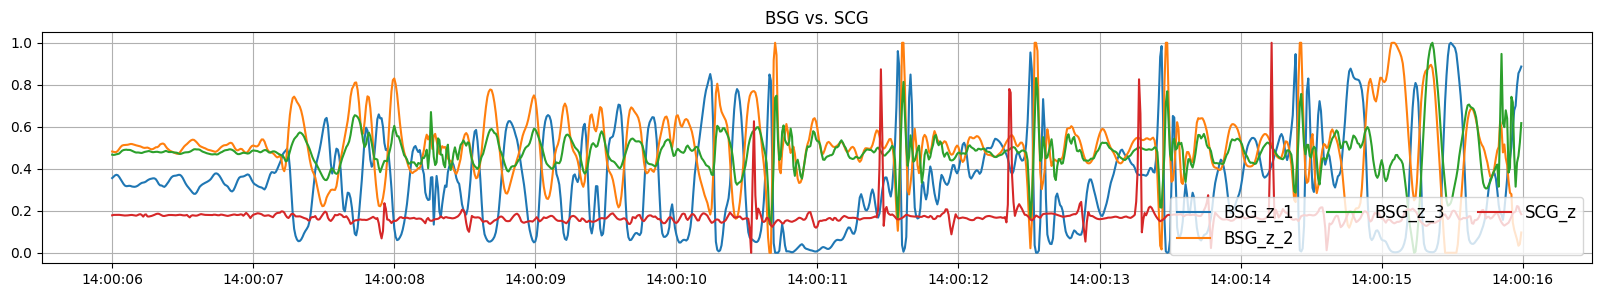

In [ ]:
start = 400
start = 8300
start = 13700
start = 24500
start = 33500
start = 39300
# start = 2500
end = start + 1000
# Reshape from (axis, chunk, simple) to (axis, signals) for easier plotting

t = pd.to_datetime(timestamps[start:end]) + pd.to_timedelta(8, unit='h')  # 转换为上海时间
t_scg = pd.to_datetime(ts_scg) + pd.to_timedelta(8, unit='h')  # 转换为上海时间
plt.figure(figsize=(20, 3))
plt.plot(t, norm_ecg(signal[2, start:end])+0, label='BSG_z_1')
plt.plot(t,norm_ecg(signal_2[2, start:end])+0, label='BSG_z_2')
plt.plot(t,norm_ecg(signal_3[2, start:end])+0, label='BSG_z_3')
shift = int(100*2.33)
plt.plot(t_scg[start:end], norm_ecg(scg_z[start+shift:end+shift]), label='SCG_z', alpha=1)
plt.legend(loc='lower right', fontsize=12, ncol=3)
plt.grid()
plt.title(f'BSG vs. SCG')

In [ ]:
# read from the original data files
# Key words
cur_trial = 1
sub = 1
selected_bed = bed_AF_ID_30_compare

In [ ]:
tt = date_time.astype("int64") // 10**6
pd.to_datetime(tt[0], unit='ns'), pd.to_datetime(tt[-1], unit='ns')

(Timestamp('1970-01-01 00:29:33.340600'),
 Timestamp('1970-01-01 00:29:33.340976990'))

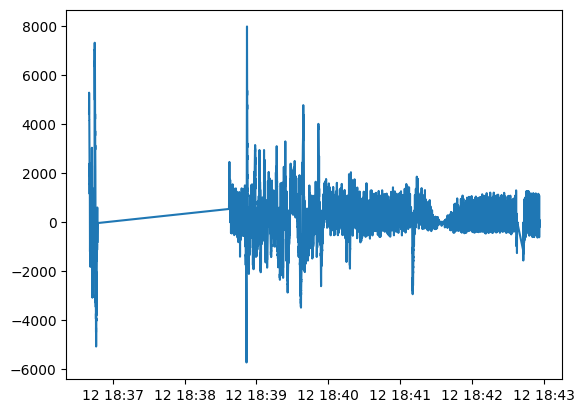

In [ ]:
plt.plot(timestamps, ecg_resampled)

In [ ]:

import neurokit2 as nk
def clean_resampled_ecg_npy(
    input_path: str = "ecg_100hz_stacked.npy",
    output_path: str = "ecg_100hz_cleaned_stacked.npy",
    fs: int = 100,
    method: str = "neurokit"
):
    """
    读取 [timestamp_ns, ecg] 的 stacked npy，
    用 neurokit2 对 ECG 做去噪/清洗，并进一步去趋势，
    最后保存成新的 stacked npy。

    Parameters
    ----------
    input_path : str
        输入的 stacked npy 文件路径
    output_path : str
        输出的 cleaned stacked npy 文件路径
    fs : int
        采样率，默认 100 Hz
    method : str
        nk.ecg_clean 的方法，默认 "neurokit"
        可选如: "neurokit", "biosppy", "pantompkins1985", "hamilton2002", ...

    Returns
    -------
    cleaned_stacked : np.ndarray
        shape = (N, 2)
        [:, 0] = timestamp_ns
        [:, 1] = cleaned_ecg
    """

    # -------------------------
    # Step 1: 读取数据
    # -------------------------
    data = np.load(input_path)

    if data.ndim != 2 or data.shape[1] != 2:
        raise ValueError(f"输入数据 shape 应为 (N, 2)，当前为 {data.shape}")

    timestamp_ns = data[:, 0].astype(np.int64)
    ecg = data[:, 1].astype(np.float64)

    # -------------------------
    # Step 2: ECG 清洗（滤波 / 去噪）
    # -------------------------
    ecg_cleaned = nk.ecg_clean(ecg, sampling_rate=fs, method=method)

    # -------------------------
    # Step 3: 去趋势
    # order=1 常用于移除缓慢漂移
    # regularization 更平滑一些，也可换成 "polynomial"
    # -------------------------
    ecg_detrended = nk.signal_detrend(
        ecg_cleaned,
        method="polynomial",
        order=1
    )

    # -------------------------
    # Step 4: stack 保存
    # -------------------------
    cleaned_stacked = np.column_stack([
        timestamp_ns.astype(np.float64),
        ecg_detrended.astype(np.float64)
    ])

    np.save(output_path, cleaned_stacked)

    # 打印一些信息
    timestamps = pd.to_datetime(timestamp_ns)
    print(f"Input file: {input_path}")
    print(f"Output file: {output_path}")
    print(f"Shape: {cleaned_stacked.shape}")
    print(f"Start time: {timestamps.iloc[0] if hasattr(timestamps, 'iloc') else timestamps[0]}")
    print(f"End time:   {timestamps.iloc[-1] if hasattr(timestamps, 'iloc') else timestamps[-1]}")
    print(f"ECG mean before: {np.mean(ecg):.6f}")
    print(f"ECG std before:  {np.std(ecg):.6f}")
    print(f"ECG mean after:  {np.mean(ecg_detrended):.6f}")
    print(f"ECG std after:   {np.std(ecg_detrended):.6f}")

    return cleaned_stacked



cleaned_data = clean_resampled_ecg_npy(
    input_path="ecg_100hz_stacked.npy",
    output_path="ecg_100hz_cleaned_stacked.npy",
    fs=100,
    method="neurokit"
)

Input file: ecg_100hz_stacked.npy
Output file: ecg_100hz_cleaned_stacked.npy
Shape: (26200, 2)
Start time: 2026-03-12 18:36:40
End time:   2026-03-12 18:41:01.990000128
ECG mean before: 1.569593
ECG std before:  830.494206
ECG mean after:  0.000000
ECG std after:   421.468242


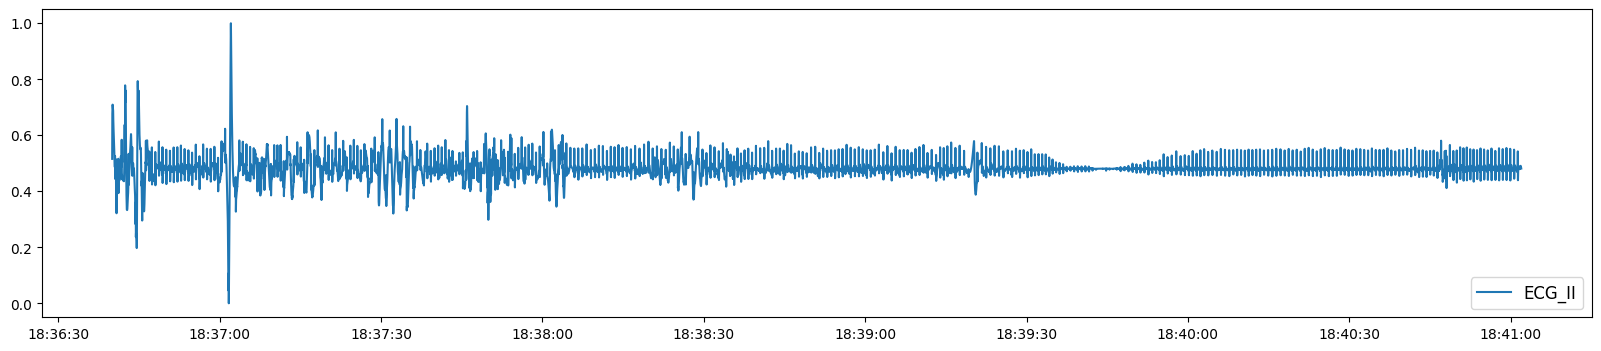

In [ ]:
# plot the signal
ecg = stacked[:, 1]
timestamps = pd.to_datetime(stacked[:, 0].astype(np.int64), unit='ns')
plt.figure(figsize=(20, 4))
plt.plot(timestamps[:], norm_ecg(ecg[:]), label='ECG_II')
plt.legend(loc='lower right', fontsize=12)